<a href="https://colab.research.google.com/github/katjanieberle/sparks/blob/main/SPARKS_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Methods: A Practical Project

## **Course**: Media & Data - University Sparks Munich, 5th Semester
## **Topic**: Supervised Learning Methods

Welcome to this learning project designed for students in the 5th semester of Media & Data at University Sparks Munich. In this project, we will explore various supervised learning methods using a real-world dataset. The goal is to understand the theoretical concepts behind these algorithms and apply them practically to predict a target variable.

## 1. Introduction to the Dataset: Social Media Advertising

We will be working with a dataset named `social_media_advertising.csv`. This dataset typically contains information about users who were exposed to a social media advertisement and whether they subsequently made a purchase. This is a classic classification problem, where we aim to predict a binary outcome (e.g., 'Purchased' or 'Not Purchased').

**Dataset Columns (typical)**:
*   `User ID`: Unique identifier for each user.
*   `Gender`: Gender of the user (e.g., Male, Female).
*   `Age`: Age of the user.
*   `EstimatedSalary`: Estimated salary of the user.
*   `Purchased`: The target variable, indicating whether the user purchased the product after seeing the ad (0 for No, 1 for Yes).

### 1.1 Loading the Data

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the provided URL
data_url = 'https://raw.githubusercontent.com/katjanieberle/sparks/main/social_media_advertising.csv'
df = pd.read_csv(data_url)

# Display the first 5 rows of the DataFrame to get an initial look at the data
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony


### 1.2 Initial Data Exploration

In [9]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
print("\nDescriptive Statistics:")
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       150000 non-null  int64  
 1   Target_Audience   150000 non-null  object 
 2   Campaign_Goal     150000 non-null  object 
 3   Duration          150000 non-null  object 
 4   Channel_Used      150000 non-null  object 
 5   Conversion_Rate   150000 non-null  float64
 6   Acquisition_Cost  150000 non-null  object 
 7   ROI               150000 non-null  float64
 8   Location          150000 non-null  object 
 9   Language          150000 non-null  object 
 10  Clicks            150000 non-null  int64  
 11  Impressions       150000 non-null  int64  
 12  Engagement_Score  150000 non-null  int64  
 13  Customer_Segment  150000 non-null  object 
 14  Date              150000 non-null  object 
 15  Company           150000 non-null  object 
dtypes: 

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,549975.911613,0.080009,3.181524,9307.592420,29401.674087,4.375547
std,260792.068387,0.040555,2.461604,5536.215779,16381.375019,3.154361
min,100003.000000,0.010000,0.000000,293.000000,1937.000000,1.000000
25%,323819.250000,0.050000,0.930000,4626.000000,15514.000000,1.000000
50%,550575.000000,0.080000,2.680000,8821.000000,28362.000000,4.000000
75%,776507.750000,0.110000,5.330000,13677.250000,42033.000000,7.000000
max,999998.000000,0.150000,8.000000,20249.000000,61499.000000,10.000000


In [10]:
# Check for missing values in each column
print("\nMissing values per column:")
display(df.isnull().sum())

# Create a binary 'Purchased' target variable based on Conversion_Rate (e.g., above median is 'Purchased')
# This is a common way to create a binary classification target when one is not explicitly provided.
median_conversion_rate = df['Conversion_Rate'].median()
df['Purchased'] = (df['Conversion_Rate'] > median_conversion_rate).astype(int)

# Check the distribution of the newly created target variable 'Purchased'
print("\nDistribution of 'Purchased' variable:")
display(df['Purchased'].value_counts())
display(df['Purchased'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Missing values per column:


,0
Campaign_ID,0
Target_Audience,0
Campaign_Goal,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0
Language,0



Distribution of 'Purchased' variable:


,count
Purchased,
0,80472
1,69528


,proportion
Purchased,
0,53.65%
1,46.35%


### 1.3 Visualizing Data Distributions

Let's visualize the distribution of key features to understand their characteristics.

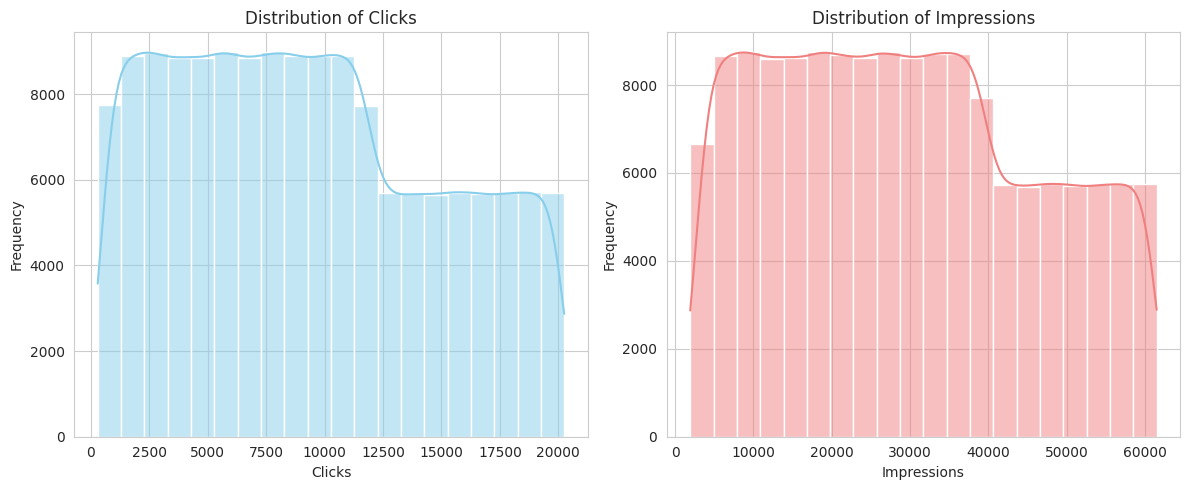

In [11]:
# Set up the visualization style
sns.set_style("whitegrid")

# Plot histograms for 'Clicks' and 'Impressions' as they are numerical features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Clicks'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Clicks')
plt.xlabel('Clicks')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['Impressions'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Impressions')
plt.xlabel('Impressions')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5296/3393252076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Channel_Used', data=df, palette='viridis', order=df['Channel_Used'].value_counts().index)


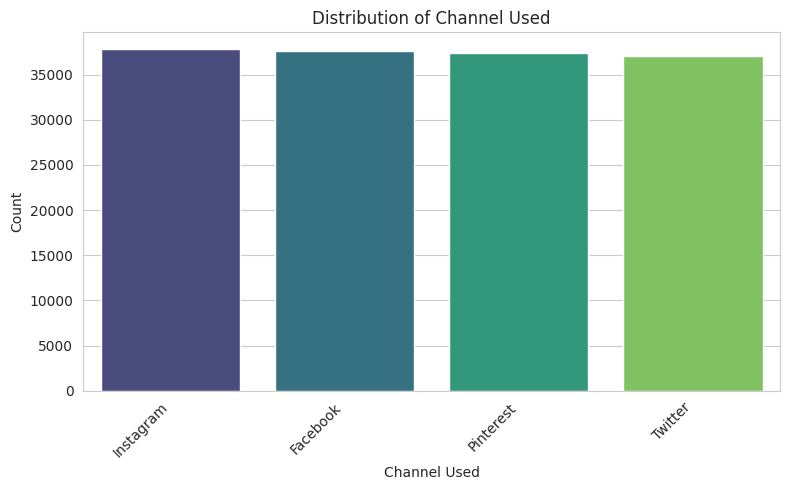

In [12]:
# Plot the distribution of 'Channel_Used' as it is a categorical feature
plt.figure(figsize=(8, 5))
sns.countplot(x='Channel_Used', data=df, palette='viridis', order=df['Channel_Used'].value_counts().index)
plt.title('Distribution of Channel Used')
plt.xlabel('Channel Used')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if many categories
plt.tight_layout()
plt.show()

### 1.4 Relationship between Features and Target Variable

Let's explore how 'Age' and 'EstimatedSalary' relate to the 'Purchased' outcome.

/tmp/ipykernel_5296/814911327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Purchased', y='Clicks', data=df, palette='coolwarm')
/tmp/ipykernel_5296/814911327.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Purchased', y='Engagement_Score', data=df, palette='coolwarm')


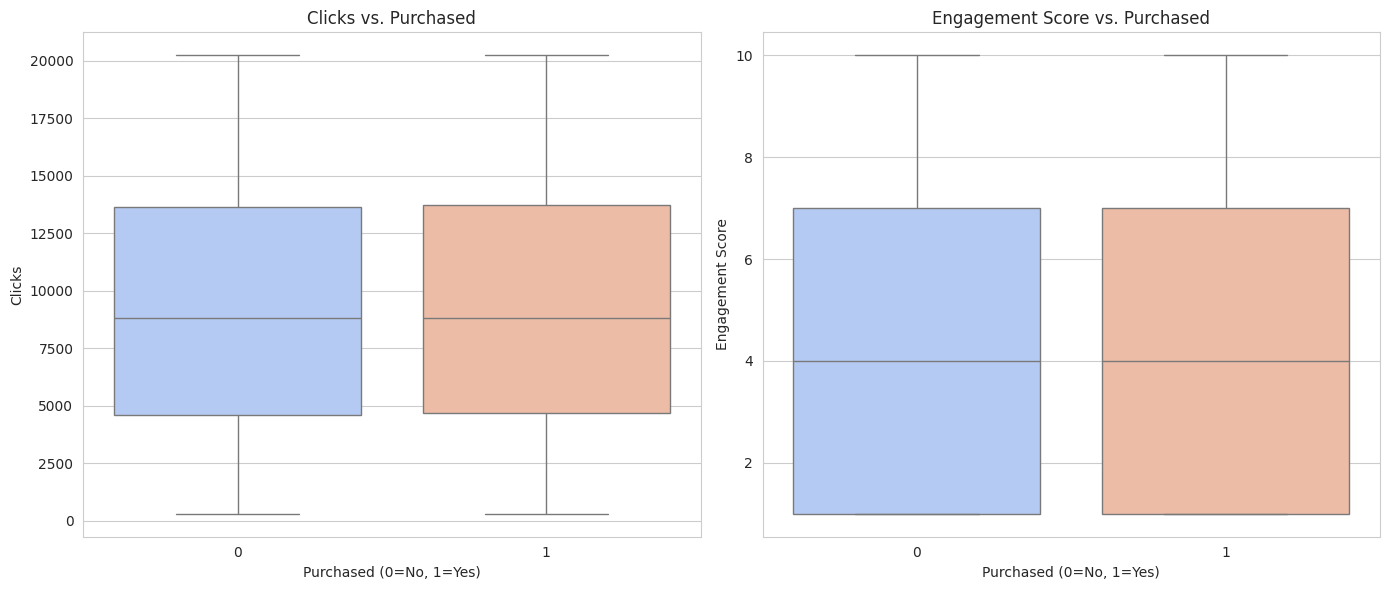

In [13]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Purchased', y='Clicks', data=df, palette='coolwarm')
plt.title('Clicks vs. Purchased')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Clicks')

plt.subplot(1, 2, 2)
sns.boxplot(x='Purchased', y='Engagement_Score', data=df, palette='coolwarm')
plt.title('Engagement Score vs. Purchased')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Engagement Score')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing for Supervised Learning

Before applying any supervised learning algorithms, it's crucial to preprocess our data. This involves handling categorical features, scaling numerical features, and splitting the data into training and testing sets.

### 2.1 Encoding Categorical Features

The 'Gender' column is a categorical variable ('Male', 'Female'). Most machine learning algorithms require numerical input, so we need to convert this column into a numerical format. We will use one-hot encoding for this purpose.

In [14]:
# Convert 'Channel_Used' column to numerical using one-hot encoding
# We'll use get_dummies, which creates new columns for each category for the selected channel types
df = pd.get_dummies(df, columns=['Channel_Used'], drop_first=True, dtype=int) # drop_first=True avoids multicollinearity

# Display the updated DataFrame head to see the new encoded columns
print("DataFrame after one-hot encoding 'Channel_Used':")
display(df.head())

DataFrame after one-hot encoding 'Channel_Used':


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company,Purchased,Channel_Used_Instagram,Channel_Used_Pinterest,Channel_Used_Twitter
0,529013,Men 35-44,Product Launch,15 Days,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align,1,1,0,0
1,275352,Women 45-60,Market Expansion,15 Days,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony,0,0,0,0
2,692322,Men 45-60,Product Launch,15 Days,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit,0,1,0,0
3,675757,Men 25-34,Increase Sales,15 Days,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish,0,0,1,0
4,535900,Men 45-60,Market Expansion,15 Days,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony,1,0,1,0


### 2.2 Feature Scaling

Features like 'Age' and 'EstimatedSalary' have different scales. This can cause issues for some algorithms (e.g., gradient descent based algorithms, SVMs) where features with larger values might dominate the objective function. We will use `StandardScaler` to scale these features, transforming them to have a mean of 0 and a standard deviation of 1.

In [15]:
from sklearn.preprocessing import StandardScaler

# Define the numerical features to use for training
numerical_features = ['Clicks', 'Impressions', 'Engagement_Score']

# Define the one-hot encoded categorical features
categorical_features_encoded = [col for col in df.columns if 'Channel_Used_' in col]

# Combine all feature columns
feature_columns = numerical_features + categorical_features_encoded

# Separate features (X) and target (y)
X = df[feature_columns]
y = df['Purchased']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features (first 5 rows):")
display(X_scaled_df.head())

Scaled Features (first 5 rows):


,Clicks,Impressions,Engagement_Score,Channel_Used_Instagram,Channel_Used_Pinterest,Channel_Used_Twitter
0,-1.59091,-1.611694,0.832011,1.722923,-0.576539,-0.573399
1,-1.59091,-1.611694,0.197966,-0.580409,-0.576539,-0.573399
2,-1.59091,-1.611694,1.466056,1.722923,-0.576539,-0.573399
3,-1.62830,-1.676585,-1.070124,-0.580409,1.734487,-0.573399
4,-1.62830,-1.676585,-1.070124,-0.580409,1.734487,-0.573399


### 2.3 Splitting Data into Training and Testing Sets

To evaluate the performance of our models, we need to split our dataset into two parts: a training set and a testing set. The model will learn from the training data, and its performance will be evaluated on the unseen testing data. This helps us to assess how well the model generalizes to new data.

In [16]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (120000, 6)
Shape of X_test: (30000, 6)
Shape of y_train: (120000,)
Shape of y_test: (30000,)


## 3. Supervised Learning Methods

Now that our data is preprocessed, we can start applying various supervised learning algorithms. We will cover the following methods:

1.  **Linear Regression**
2.  **Logistic Regression**
3.  **Decision Tree Classifier**
4.  **K-Nearest Neighbors (KNN)**

For each method, we will provide a brief theoretical explanation, implement the model, train it, make predictions, and evaluate its performance.

### 3.1 Linear Regression

#### **Theory**

Linear Regression is a fundamental statistical model used to predict a continuous target variable based on one or more independent predictor variables. It assumes a linear relationship between the input features and the target. While primarily used for regression tasks (predicting numerical values), it can sometimes be adapted for classification by treating the target classes as numerical values (e.g., 0 and 1) and then setting a threshold on the predicted continuous output to classify. However, for binary classification, Logistic Regression is generally more appropriate as it models probabilities directly. We will implement it here to demonstrate its mechanics, acknowledging its limitations for purely binary classification.

#### **Implementation**

Training Linear Regression model...
Training complete.

--- Linear Regression Model Evaluation ---
Mean Squared Error (MSE): 0.2483
R-squared (R2): -0.0003
Accuracy (with 0.5 threshold): 0.5419

Confusion Matrix (with 0.5 threshold):
[[16256     0]
 [13744     0]]

Classification Report (with 0.5 threshold):
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16256
           1       0.00      0.00      0.00     13744

    accuracy                           0.54     30000
   macro avg       0.27      0.50      0.35     30000
weighted avg       0.29      0.54      0.38     30000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


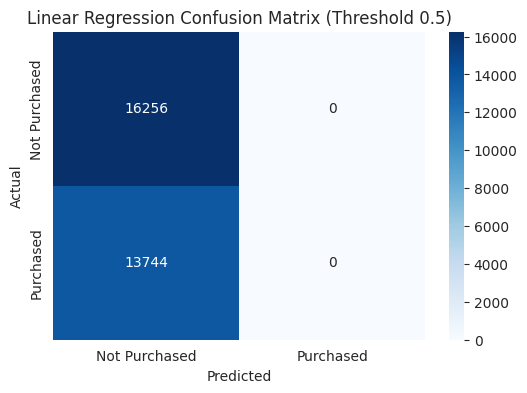

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
print("Training Linear Regression model...")
linear_reg_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_linear_reg = linear_reg_model.predict(X_test)

# For evaluation in a classification context (thresholding at 0.5)
y_pred_class_linear_reg = (y_pred_linear_reg > 0.5).astype(int)

# Evaluate the model's performance (using both regression and classification metrics)
print("\n--- Linear Regression Model Evaluation ---")

# Regression metrics
mse_linear_reg = mean_squared_error(y_test, y_pred_linear_reg)
r2_linear_reg = r2_score(y_test, y_pred_linear_reg)
print(f"Mean Squared Error (MSE): {mse_linear_reg:.4f}")
print(f"R-squared (R2): {r2_linear_reg:.4f}")

# Classification metrics (after thresholding)
accuracy_linear_reg = accuracy_score(y_test, y_pred_class_linear_reg)
print(f"Accuracy (with 0.5 threshold): {accuracy_linear_reg:.4f}")

conf_matrix_linear_reg = confusion_matrix(y_test, y_pred_class_linear_reg)
print("\nConfusion Matrix (with 0.5 threshold):")
print(conf_matrix_linear_reg)

class_report_linear_reg = classification_report(y_test, y_pred_class_linear_reg)
print("\nClassification Report (with 0.5 threshold):")
print(class_report_linear_reg)

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_linear_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.title('Linear Regression Confusion Matrix (Threshold 0.5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3.2 Logistic Regression

#### **Theory**

Logistic Regression is a linear model used for binary classification problems. Despite its name, it's a classification algorithm, not a regression algorithm. It models the probability that a given input belongs to a particular class (e.g., probability of purchasing). The logistic function (or sigmoid function) is used to map predictions to probabilities between 0 and 1. If the probability is above a certain threshold (commonly 0.5), the input is classified into one class; otherwise, it's classified into the other.

Training Logistic Regression model...
Training complete.

--- Logistic Regression Model Evaluation ---
Accuracy: 0.5419

Confusion Matrix:
[[16256     0]
 [13744     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16256
           1       0.00      0.00      0.00     13744

    accuracy                           0.54     30000
   macro avg       0.27      0.50      0.35     30000
weighted avg       0.29      0.54      0.38     30000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


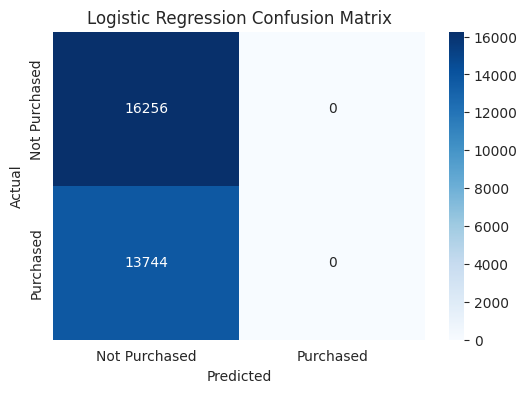

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
# random_state for reproducibility
log_reg_model = LogisticRegression(random_state=42)

# Train the model using the training data
print("Training Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model's performance
print("\n--- Logistic Regression Model Evaluation ---")

# Accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_log_reg:.4f}")

# Confusion Matrix
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(conf_matrix_log_reg)

# Classification Report (precision, recall, f1-score)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
print("\nClassification Report:")
print(class_report_log_reg)

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3.3 Decision Tree Classifier

#### **Theory**

Decision Trees are non-parametric supervised learning methods used for classification and regression. They work by splitting the data into subsets based on feature values, forming a tree-like structure of decisions. Each internal node represents a test on an attribute, each branch represents an outcome of the test, and each leaf node represents a class label (in classification) or a predicted value (in regression). Decision trees are intuitive and easy to interpret, but can be prone to overfitting, especially with complex trees.

Training Decision Tree Classifier...
Training complete.

--- Decision Tree Classifier Model Evaluation ---
Accuracy: 0.5415

Confusion Matrix:
[[16209    47]
 [13709    35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16256
           1       0.43      0.00      0.01     13744

    accuracy                           0.54     30000
   macro avg       0.48      0.50      0.35     30000
weighted avg       0.49      0.54      0.38     30000



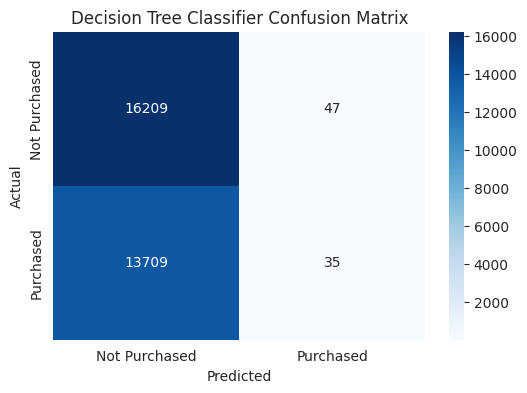

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Decision Tree Classifier
# random_state for reproducibility; max_depth to control overfitting
decision_tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the model
print("Training Decision Tree Classifier...")
decision_tree_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model's performance
print("\n--- Decision Tree Classifier Model Evaluation ---")

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")

# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(conf_matrix_dt)

# Classification Report
class_report_dt = classification_report(y_test, y_pred_dt)
print("\nClassification Report:")
print(class_report_dt)

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.title('Decision Tree Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3.4 K-Nearest Neighbors (KNN)

#### **Theory**

K-Nearest Neighbors (KNN) is a non-parametric, lazy learning algorithm used for both classification and regression. In KNN classification, an object is classified by a majority vote of its neighbors, with the object being assigned to the class most common among its `k` nearest neighbors. The 'distance' between neighbors is calculated using metrics like Euclidean distance. KNN is simple to understand and implement, but can be computationally expensive for large datasets and sensitive to irrelevant features and the scale of the data.

Training K-Nearest Neighbors Classifier...
Training complete.

--- K-Nearest Neighbors Classifier Model Evaluation ---
Accuracy: 0.5032

Confusion Matrix:
[[9137 7119]
 [7786 5958]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55     16256
           1       0.46      0.43      0.44     13744

    accuracy                           0.50     30000
   macro avg       0.50      0.50      0.50     30000
weighted avg       0.50      0.50      0.50     30000



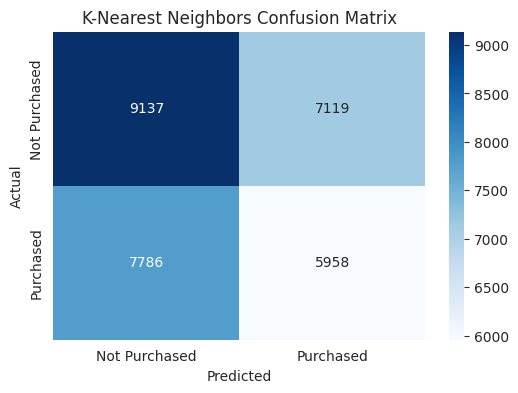

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the K-Nearest Neighbors Classifier
# n_neighbors specifies the number of neighbors to consider
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
print("Training K-Nearest Neighbors Classifier...")
knn_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model's performance
print("\n--- K-Nearest Neighbors Classifier Model Evaluation ---")

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.4f}")

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# Classification Report
class_report_knn = classification_report(y_test, y_pred_knn)
print("\nClassification Report:")
print(class_report_knn)

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()